## Try 9.5.1: Visualizing the breast cancer dataset.

**The Python code below imports the breast cancer dataset and compares benign and malignant cells using box plots.**

* **Click the double-right arrow to restart the kernel and run all cells.**
* **Examine the code below.**
* **Modify the code to explore different features.**

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import and code data
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score , accuracy_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
cancer = pd.read_csv('WisconsinBreastCancerDatabase.csv').dropna()
cancer

,ID,Diagnosis,Radius mean,Texture mean,Perimeter mean,Area mean,Smoothness mean,Compactness mean,Concavity mean,Concave points mean,...,Radius worst,Texture worst,Perimeter worst,Area worst,Smoothness worst,Compactness worst,Concavity worst,Concave points worst,Symmetry worst,Fractal dimension worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
cancer['Diagnosis'] = cancer['Diagnosis'].apply(lambda x: 1 if x == 'M' else 0)
cancer

,ID,Diagnosis,Radius mean,Texture mean,Perimeter mean,Area mean,Smoothness mean,Compactness mean,Concavity mean,Concave points mean,...,Radius worst,Texture worst,Perimeter worst,Area worst,Smoothness worst,Compactness worst,Concavity worst,Concave points worst,Symmetry worst,Fractal dimension worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
from collections import Counter
print(Counter(cancer['Diagnosis']))

Counter({0: 357, 1: 212})


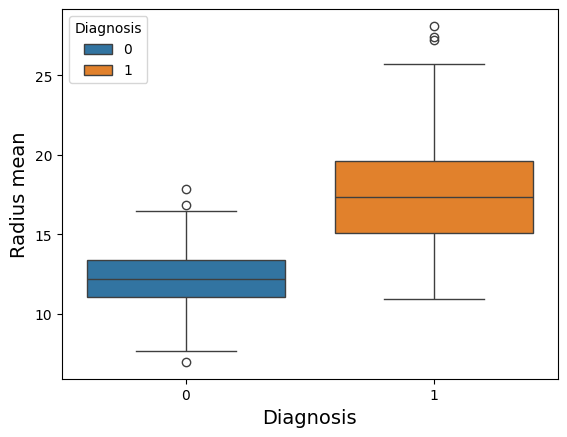

In [6]:
# Plot boxplot
p = sns.boxplot(data=cancer, x='Diagnosis', y='Radius mean', hue='Diagnosis')
p.set_xlabel('Diagnosis', fontsize=14)
p.set_ylabel('Radius mean', fontsize=14)
plt.show()

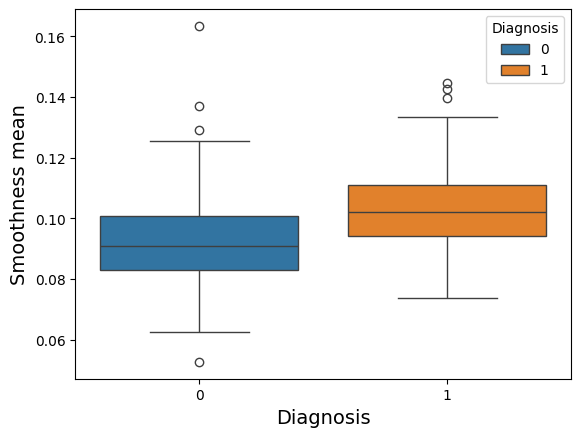

In [7]:
# Plot boxplot
p = sns.boxplot(data=cancer, x='Diagnosis', y='Smoothness mean', hue='Diagnosis')
p.set_xlabel('Diagnosis', fontsize=14)
p.set_ylabel('Smoothness mean', fontsize=14)
plt.show()

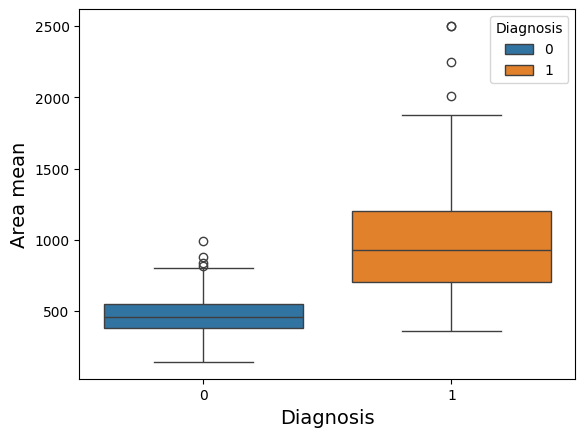

In [8]:
# Plot boxplot
p = sns.boxplot(data=cancer, x='Diagnosis', y='Area mean', hue='Diagnosis')
p.set_xlabel('Diagnosis', fontsize=14)
p.set_ylabel('Area mean', fontsize=14)
plt.show()

## Try 9.5.2: Classifying cells using k-nearest neighbors.

**The Python code below imports the breast cancer dataset and fits k-nearest neighbors for classification with k=3, 7, and 11 to a training dataset.**

* **Click the double-right arrow to restart the kernel and run all cells.**
* **Examine the code below.**
* **Modify the code to explore the effect of additional input features or different values of k.**

In [9]:
from sklearn.neighbors import KNeighborsClassifier

In [10]:
cancer

,ID,Diagnosis,Radius mean,Texture mean,Perimeter mean,Area mean,Smoothness mean,Compactness mean,Concavity mean,Concave points mean,...,Radius worst,Texture worst,Perimeter worst,Area worst,Smoothness worst,Compactness worst,Concavity worst,Concave points worst,Symmetry worst,Fractal dimension worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### The following Participation Activities may have slightly different values due to randomization. Students are encouraged to explore the analysis by changing the seed value, but should answer the PA questions using seed=123.

In [11]:
seed = 123

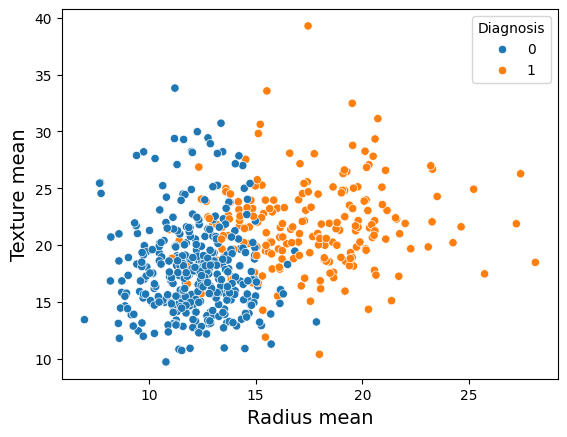

In [12]:
# Visual exploration
p = sns.scatterplot(data=cancer, x='Radius mean', y='Texture mean', hue='Diagnosis')
p.set_xlabel('Radius mean', fontsize=14)
p.set_ylabel('Texture mean', fontsize=14)
plt.show()

In [13]:
# Define input and output features
X = cancer[['Radius mean', 'Texture mean']]
y = cancer[['Diagnosis']]

# Create training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

# Scale the input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Fit k-nearest neighbors with k=3
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_scaled, np.ravel(y_train))

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


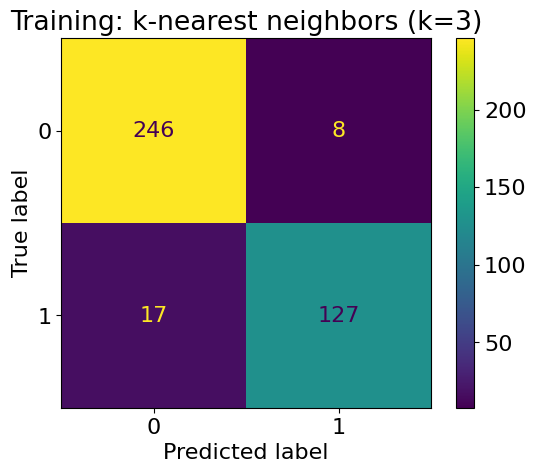

In [15]:
# Confusion matrix
y_pred = knn3.predict(X_train_scaled)

plt.rcParams.update({'font.size': 16})
cmTrain = confusion_matrix(y_train, y_pred)
cmTrain_plot = ConfusionMatrixDisplay(
    confusion_matrix=cmTrain, display_labels=knn3.classes_
)
cmTrain_plot.plot()
cmTrain_plot.ax_.set_title('Training: k-nearest neighbors (k=3)')
plt.show()

In [16]:
# Calculate accuracy, precision, and recall
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)

Accuracy: 0.9371859296482412
Precision: 0.9407407407407408
Recall: 0.8819444444444444


In [17]:
# Fit k-nearest neighbors with k=7
knn7 = KNeighborsClassifier(n_neighbors=7)
knn7.fit(X_train_scaled, np.ravel(y_train))

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


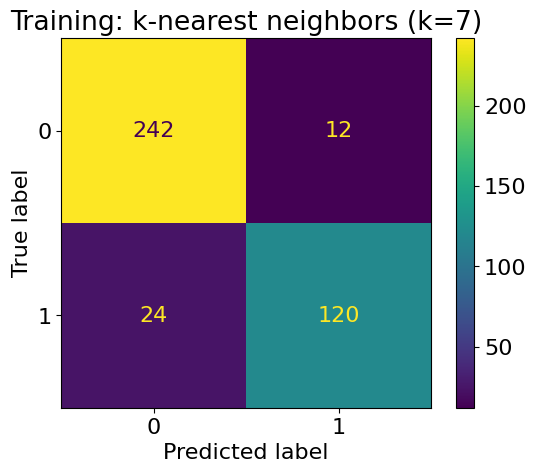

In [18]:
# Confusion matrix
y_pred = knn7.predict(X_train_scaled)

plt.rcParams.update({'font.size': 16})
cmTrain = confusion_matrix(y_train, y_pred)
cmTrain_plot = ConfusionMatrixDisplay(
    confusion_matrix=cmTrain, display_labels=knn7.classes_
)
cmTrain_plot.plot()
cmTrain_plot.ax_.set_title('Training: k-nearest neighbors (k=7)')
plt.show()

In [19]:
# Calculate accuracy, precision, and recall
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)

Accuracy: 0.9095477386934674
Precision: 0.9090909090909091
Recall: 0.8333333333333334


In [20]:
# Fit k-nearest neighbors with k=11
knn11 = KNeighborsClassifier(n_neighbors=11)
knn11.fit(X_train_scaled, np.ravel(y_train))

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


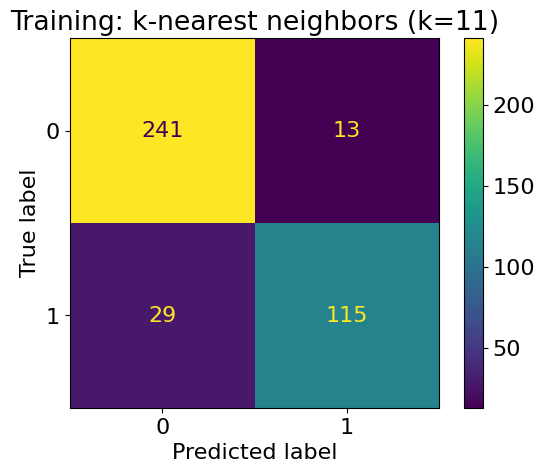

In [21]:
# Confusion matrix
y_pred = knn11.predict(X_train_scaled)

plt.rcParams.update({'font.size': 16})
cmTrain = confusion_matrix(y_train, y_pred)
cmTrain_plot = ConfusionMatrixDisplay(
    confusion_matrix=cmTrain, display_labels=knn11.classes_
)
cmTrain_plot.plot()
cmTrain_plot.ax_.set_title('Training: k-nearest neighbors (k=11)')
plt.show()

In [22]:
# Calculate accuracy, precision, and recall
accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)

Accuracy: 0.8944723618090452
Precision: 0.8984375
Recall: 0.7986111111111112


## Try 9.5.3: Classifying cells using support vector classifiers.

**The Python code below imports the breast cancer dataset and fits three support vector classifiers. Each support vector model uses a different basis function.**

* **Click the double-right arrow to restart the kernel and run all cells.**
* **Examine the code below.**
* **Modify the code to explore the effect of additional input features.**

In [23]:
from sklearn import svm

In [24]:
cancer

,ID,Diagnosis,Radius mean,Texture mean,Perimeter mean,Area mean,Smoothness mean,Compactness mean,Concavity mean,Concave points mean,...,Radius worst,Texture worst,Perimeter worst,Area worst,Smoothness worst,Compactness worst,Concavity worst,Concave points worst,Symmetry worst,Fractal dimension worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### The following Participation Activities may have slightly different values due to randomization. Students are encouraged to explore the analysis by changing the seed value, but should answer the PA questions using seed=123.

In [25]:
seed=123

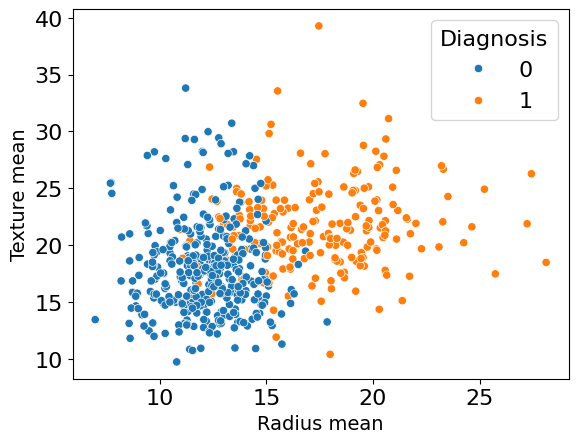

In [26]:
# Visual exploration
p = sns.scatterplot(data=cancer, x='Radius mean', y='Texture mean', hue='Diagnosis')
p.set_xlabel('Radius mean', fontsize=14)
p.set_ylabel('Texture mean', fontsize=14)
plt.show()

In [27]:
# Define input and output features
X = cancer[['Radius mean', 'Texture mean']]
y = cancer[['Diagnosis']]

# Create training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

# Scale the input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Fit SVM
linearSVM = svm.SVC(kernel='linear')
linearSVM.fit(X_train_scaled, y_train.values.ravel())

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


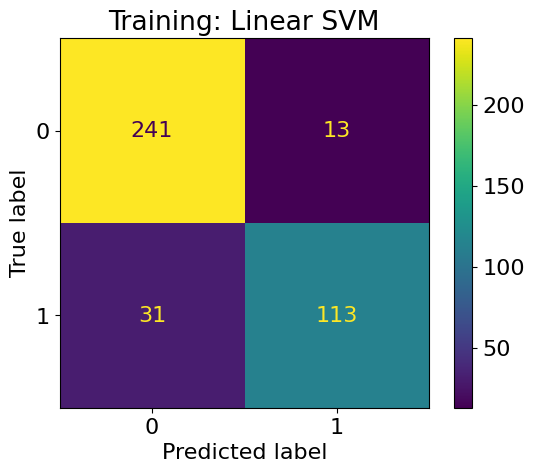

In [29]:
# Confusion matrix
y_pred = linearSVM.predict(X_train_scaled)
cmTrain = confusion_matrix(y_train, y_pred)

plt.rcParams.update({'font.size': 16})
cmTrain_plot = ConfusionMatrixDisplay(
    confusion_matrix=cmTrain, display_labels=linearSVM.classes_
)
cmTrain_plot.plot()
cmTrain_plot.ax_.set_title('Training: Linear SVM')
plt.show()

In [30]:
# Fit SVM
rbfSVM = svm.SVC(kernel='rbf')
rbfSVM.fit(X_train_scaled, y_train.values.ravel())

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


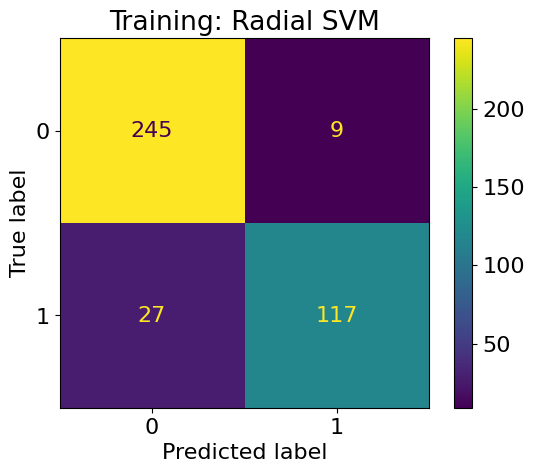

In [31]:
# Confusion matrix
y_pred = rbfSVM.predict(X_train_scaled)
cmTrain = confusion_matrix(y_train, y_pred)

plt.rcParams.update({'font.size': 16})
cmTrain_plot = ConfusionMatrixDisplay(
    confusion_matrix=cmTrain, display_labels=rbfSVM.classes_
)
cmTrain_plot.plot()
cmTrain_plot.ax_.set_title('Training: Radial SVM')
plt.show()

In [32]:
# Fit SVM
polySVM = svm.SVC(kernel='poly')
polySVM.fit(X_train_scaled, y_train.values.ravel())

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


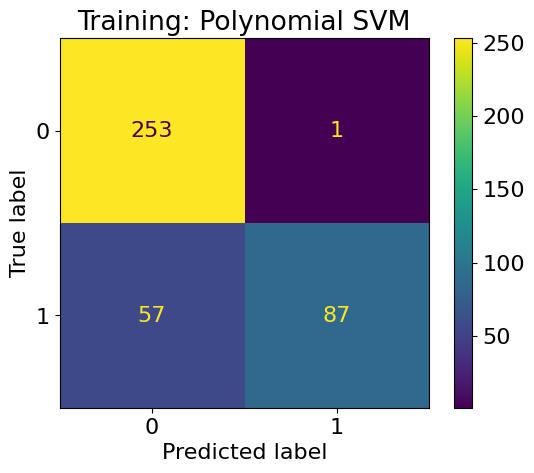

In [33]:
# Confusion matrix
y_pred = polySVM.predict(X_train_scaled)
cmTrain = confusion_matrix(y_train, y_pred)

plt.rcParams.update({'font.size': 16})
cmTrain_plot = ConfusionMatrixDisplay(
    confusion_matrix=cmTrain, display_labels=polySVM.classes_
)
cmTrain_plot.plot()
cmTrain_plot.ax_.set_title('Training: Polynomial SVM')
plt.show()

## Try 9.5.4: Comparing classification models for the breast cancer dataset.

**The Python code below imports the breast cancer dataset, and fits six classification models using all input features.**

* **Click the double-right arrow to restart the kernel and run all cells.**
* **Examine the code below. Compare and contrast training vs. testing accuracy for the six models.**

In [34]:
cancer.shape

(569, 32)

#### The following Participation Activities may have slightly different values due to randomization. Students are encouraged to explore the analysis by changing the seed value, but should answer the PA questions using seed=123.

In [35]:
seed = 123

In [36]:
# Define input and output features
# Remove ID and diagnosis from X
X = cancer.iloc[:, 2:33]
y = cancer[['Diagnosis']]

# Create training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

# Scale the input features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
y_train.describe()

,Diagnosis
count,398.000000
mean,0.361809
std,0.481129
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [38]:
y_test.describe()

,Diagnosis
count,171.000000
mean,0.397661
std,0.490852
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [39]:
# Fit k-nearest neighbors with k=3
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_scaled, np.ravel(y_train))

# Fit k-nearest neighbors with k=7
knn7 = KNeighborsClassifier(n_neighbors=7)
knn7.fit(X_train_scaled, np.ravel(y_train))

# Fit k-nearest neighbors with k=11
knn11 = KNeighborsClassifier(n_neighbors=11)
knn11.fit(X_train_scaled, np.ravel(y_train))

# Fit linear support vector classifier
linearSVM = svm.SVC(kernel='linear')
linearSVM.fit(X_train_scaled, y_train.values.ravel())

# Fit radial support vector classifier
rbfSVM = svm.SVC(kernel='rbf')
rbfSVM.fit(X_train_scaled, y_train.values.ravel())

# Fit polynomial support vector classifier
polySVM = svm.SVC(kernel='poly')
polySVM.fit(X_train_scaled, y_train.values.ravel())

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [40]:
# Calculate scores on training for all models
train_scores = [
    knn3.score(X_train_scaled, y_train),
    knn7.score(X_train_scaled, y_train),
    knn11.score(X_train_scaled, y_train),
    linearSVM.score(X_train_scaled, y_train),
    rbfSVM.score(X_train_scaled, y_train),
    polySVM.score(X_train_scaled, y_train),
]

train_scores

[0.9798994974874372,
 0.9673366834170855,
 0.964824120603015,
 0.9874371859296482,
 0.9824120603015075,
 0.9120603015075377]

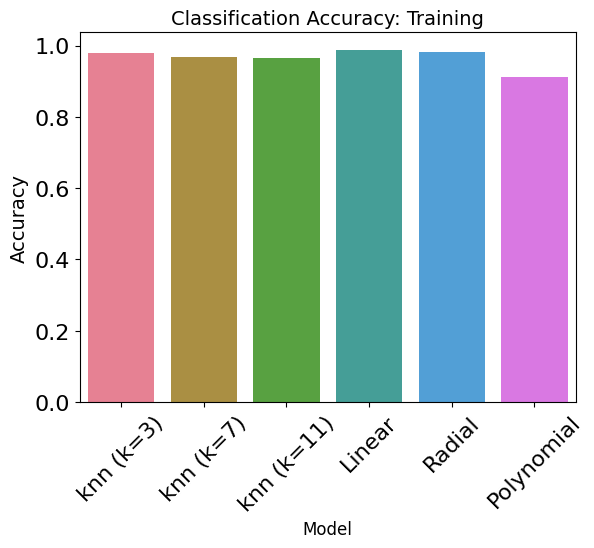

In [41]:
model = ['knn (k=3)', 'knn (k=7)', 'knn (k=11)', 'Linear', 'Radial', 'Polynomial']



# Create a colorful barplot
p = sns.barplot(x=model, y=train_scores, hue=model,palette='husl')  # or try 'husl', 'pastel', etc.

# Labeling
p.set_xlabel('Model', fontsize=12)
plt.xticks(rotation=45)
p.set_ylabel('Accuracy', fontsize=14)
p.set_title('Classification Accuracy: Training', fontsize=14)

# Show plot
plt.show()

In [42]:
# Calculate scores on testing for all models
test_scores = [
    knn3.score(X_test_scaled, y_test),
    knn7.score(X_test_scaled, y_test),
    knn11.score(X_test_scaled, y_test),
    linearSVM.score(X_test_scaled, y_test),
    rbfSVM.score(X_test_scaled, y_test),
    polySVM.score(X_test_scaled, y_test),
]

test_scores

[0.9883040935672515,
 0.9766081871345029,
 0.9824561403508771,
 0.9883040935672515,
 0.9824561403508771,
 0.8771929824561403]

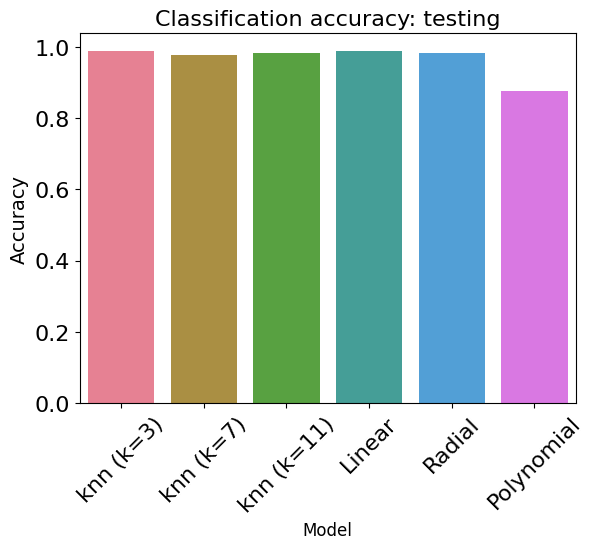

In [43]:
# Plot scores on testing for all models
p = sns.barplot(x=model, y=test_scores, hue=model, palette='husl', legend=False)
p.set_xlabel('Model', fontsize=12)
plt.xticks(rotation=45)
p.set_ylabel('Accuracy', fontsize=14)
p.set_title('Classification accuracy: testing', fontsize=16)
plt.show()

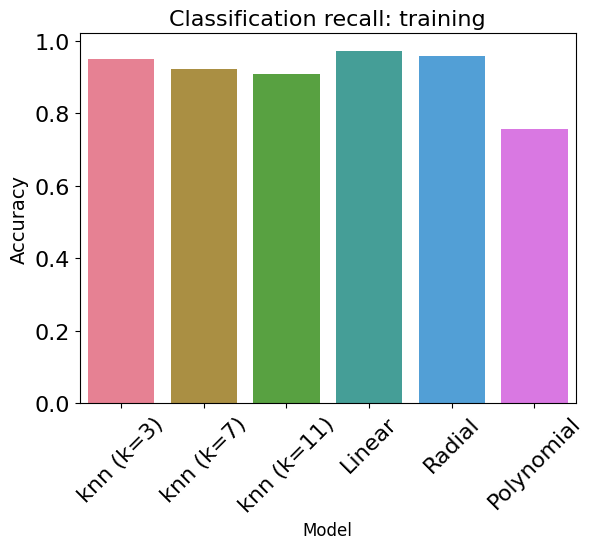

In [44]:
# Calculate recall on training for all models
train_recall = [
    recall_score(y_train, knn3.predict(X_train_scaled)),
    recall_score(y_train, knn7.predict(X_train_scaled)),
    recall_score(y_train, knn11.predict(X_train_scaled)),
    recall_score(y_train, linearSVM.predict(X_train_scaled)),
    recall_score(y_train, rbfSVM.predict(X_train_scaled)),
    recall_score(y_train, polySVM.predict(X_train_scaled)),
]


p = sns.barplot(x=model, y=train_recall, hue=model, palette='husl', legend=False)

p.set_xlabel('Model', fontsize=12)
plt.xticks(rotation=45)
p.set_ylabel('Accuracy', fontsize=14)
p.set_title('Classification recall: training', fontsize=16)
plt.show()

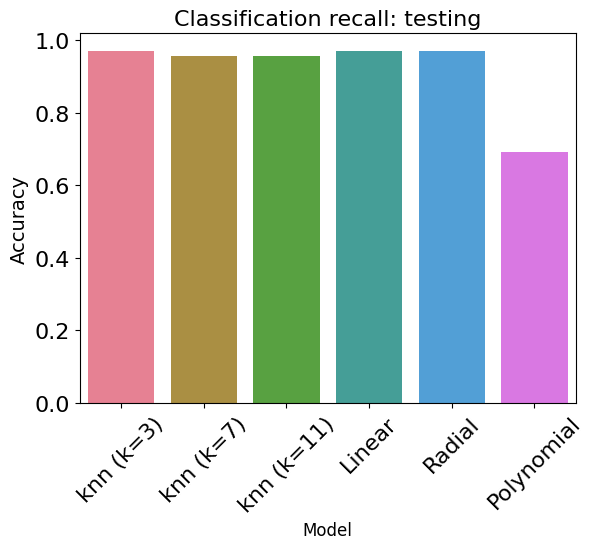

In [45]:
# Calculate recall on testing for all models
test_recall = [
    recall_score(y_test, knn3.predict(X_test_scaled)),
    recall_score(y_test, knn7.predict(X_test_scaled)),
    recall_score(y_test, knn11.predict(X_test_scaled)),
    recall_score(y_test, linearSVM.predict(X_test_scaled)),
    recall_score(y_test, rbfSVM.predict(X_test_scaled)),
    recall_score(y_test, polySVM.predict(X_test_scaled)),
]


p = sns.barplot(x=model, y=test_recall, hue=model, palette='husl', legend=False)

p.set_xlabel('Model', fontsize=12)
plt.xticks(rotation=45)
p.set_ylabel('Accuracy', fontsize=14)
p.set_title('Classification recall: testing', fontsize=16)
plt.show()

In [46]:
test_recall

[0.9705882352941176,
 0.9558823529411765,
 0.9558823529411765,
 0.9705882352941176,
 0.9705882352941176,
 0.6911764705882353]